In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = pd.read_csv('/content/train.csv')

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [6]:
df.shape

(9800, 18)

In [7]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [9]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.drop_duplicates()

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [17]:

df['Order Date'].head(10)

,Order Date
0,08/11/2017
1,08/11/2017
2,12/06/2017
3,11/10/2016
4,11/10/2016
5,09/06/2015
6,09/06/2015
7,09/06/2015
8,09/06/2015
9,09/06/2015


In [18]:
print(df['Order Date'].dtype)

object


In [19]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

In [20]:
df['Order Date'].dtype

dtype('<M8[ns]')

In [21]:
df['Order Date'].isnull().sum()

np.int64(5841)

df.isnull().sum()

In [22]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,5841
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [24]:
df = pd.read_csv('/content/train.csv')

In [25]:

df['Order Date'].head(10)

,Order Date
0,08/11/2017
1,08/11/2017
2,12/06/2017
3,11/10/2016
4,11/10/2016
5,09/06/2015
6,09/06/2015
7,09/06/2015
8,09/06/2015
9,09/06/2015


In [26]:
df['Order Date'].dtype

dtype('O')

In [27]:
df['Order Date'].head(10)

,Order Date
0,08/11/2017
1,08/11/2017
2,12/06/2017
3,11/10/2016
4,11/10/2016
5,09/06/2015
6,09/06/2015
7,09/06/2015
8,09/06/2015
9,09/06/2015


In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [32]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

In [33]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')


In [34]:
df[['Order Date', 'Ship Date']].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


In [35]:
df[['Order Date', 'Ship Date']].isnull().sum()

,0
Order Date,5841
Ship Date,5985


In [36]:
df = pd.read_csv('/content/train.csv')


In [37]:
print(df['Order Date'].head(10).tolist())

['08/11/2017', '08/11/2017', '12/06/2017', '11/10/2016', '11/10/2016', '09/06/2015', '09/06/2015', '09/06/2015', '09/06/2015', '09/06/2015']


In [38]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    format='%d/%m/%Y'
)


In [39]:
df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    format='%d/%m/%Y'
)

In [40]:
df[['Order Date', 'Ship Date']].isnull().sum()

,0
Order Date,0
Ship Date,0


In [41]:
df[['Order Date', 'Ship Date']].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


In [43]:
df[df['Postal Code'].isnull()][['City', 'State', 'Postal Code']]

,City,State,Postal Code
2234,Burlington,Vermont,NaN
5274,Burlington,Vermont,NaN
8798,Burlington,Vermont,NaN
9146,Burlington,Vermont,NaN
9147,Burlington,Vermont,NaN
9148,Burlington,Vermont,NaN
9386,Burlington,Vermont,NaN
9387,Burlington,Vermont,NaN
9388,Burlington,Vermont,NaN
9389,Burlington,Vermont,NaN


In [44]:
df['Postal Code'].isnull().sum()

np.int64(11)

In [45]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

In [46]:
df[['Order Date', 'Year', 'Month']].head()

,Order Date,Year,Month
0,2017-11-08,2017,11
1,2017-11-08,2017,11
2,2017-06-12,2017,6
3,2016-10-11,2016,10
4,2016-10-11,2016,10


In [47]:
df['Month_Year'] = df['Order Date'].dt.to_period('M')

In [48]:
df[['Order Date', 'Month_Year']].head()

,Order Date,Month_Year
0,2017-11-08,2017-11
1,2017-11-08,2017-11
2,2017-06-12,2017-06
3,2016-10-11,2016-10
4,2016-10-11,2016-10


In [50]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Year', 'Month', 'Month_Year']


In [51]:
df['Sales'].describe()

,Sales
count,9800.000000
mean,230.769059
std,626.651875
min,0.444000
25%,17.248000
50%,54.490000
75%,210.605000
max,22638.480000


In [53]:
stats = pd.DataFrame({
    'Mean': [df['Sales'].mean()],
    'Median': [df['Sales'].median()],
    'Standard Deviation': [df['Sales'].std()]
}, index=['Sales'])

stats

,Mean,Median,Standard Deviation
Sales,230.769059,54.49,626.651875


In [54]:
monthly_sales = df.groupby('Month_Year')['Sales'].sum().reset_index()

monthly_sales.head()

,Month_Year,Sales
0,2015-01,14205.707
1,2015-02,4519.892
2,2015-03,55205.797
3,2015-04,27906.855
4,2015-05,23644.303


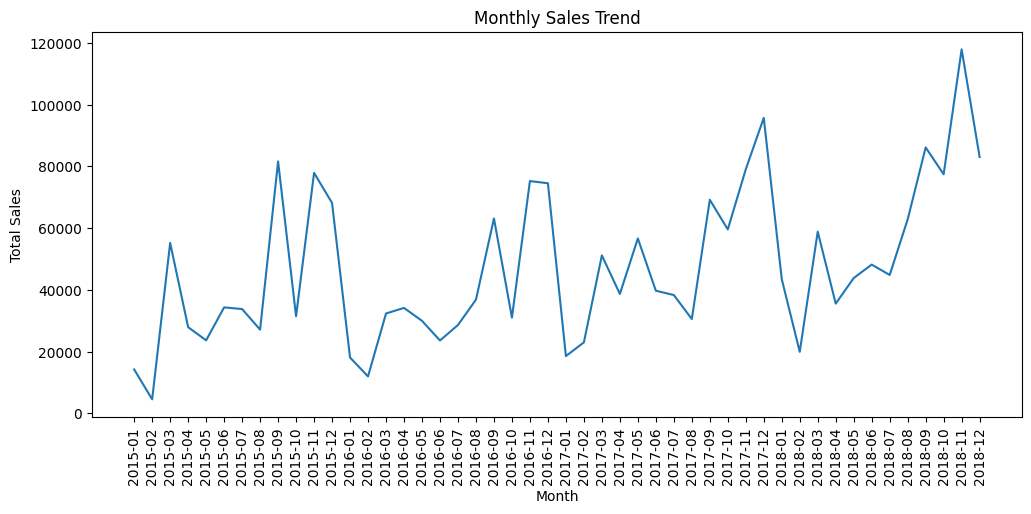

In [55]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_sales['Month_Year'].astype(str),
         monthly_sales['Sales'])

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)

plt.show()

In [56]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

category_sales

,Sales
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


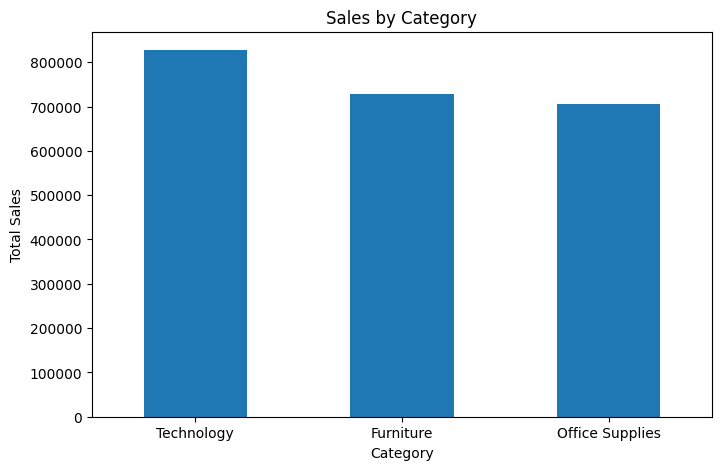

In [57]:
plt.figure(figsize=(8, 5))

category_sales.plot(kind='bar')

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.show()

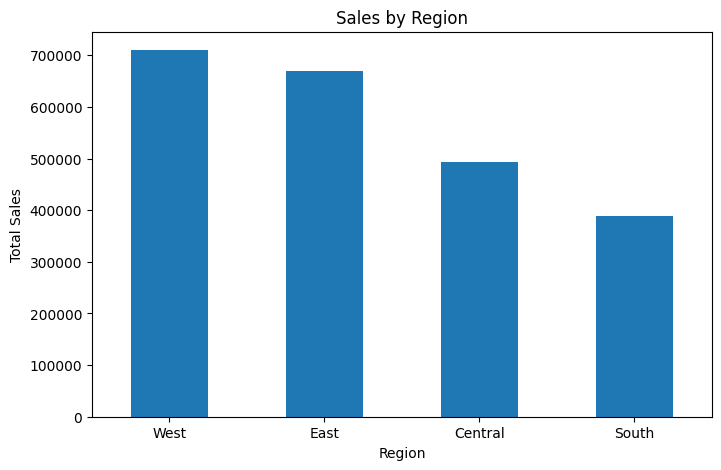

In [58]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_sales.plot(kind='bar')

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.show()



In [59]:
df.select_dtypes(include=np.number).columns

Index(['Row ID', 'Postal Code', 'Sales', 'Year', 'Month'], dtype='object')

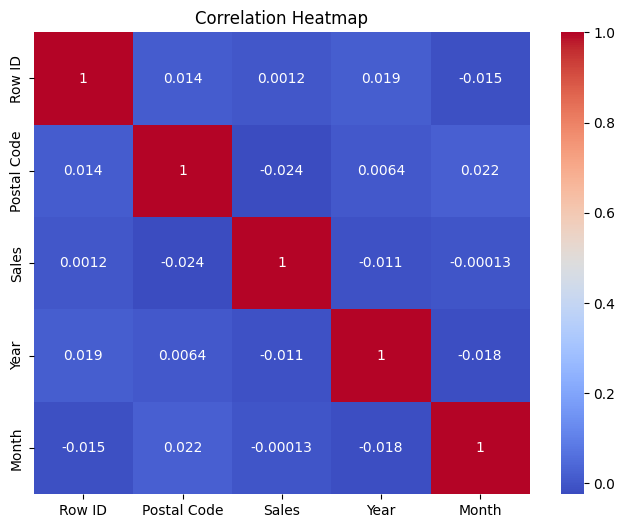

In [60]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8, 6))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

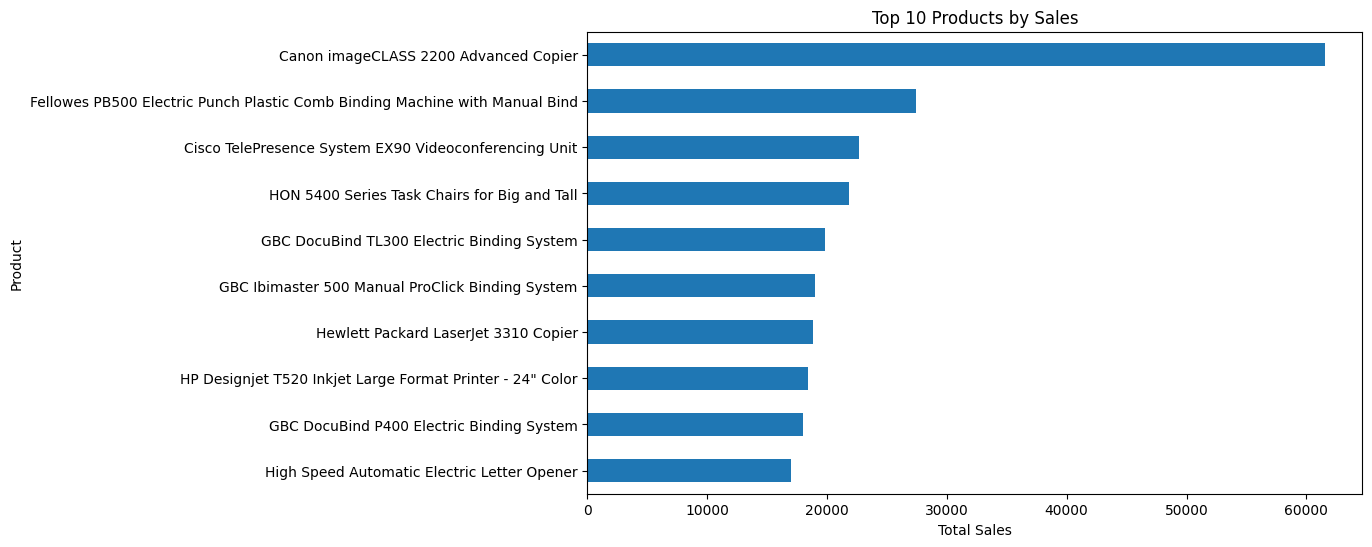

In [61]:
top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product')

plt.show()

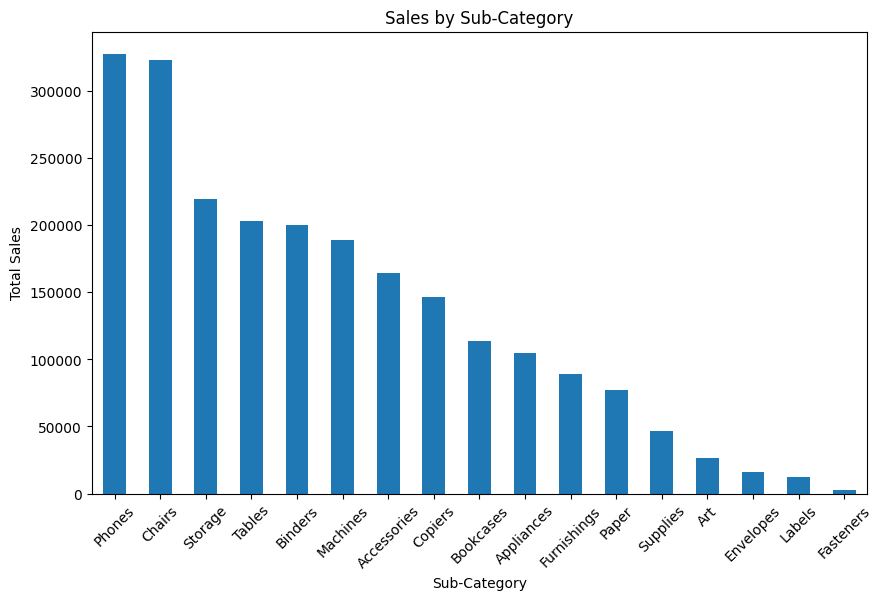

In [62]:
subcategory_sales = (
    df.groupby('Sub-Category')['Sales']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

subcategory_sales.plot(kind='bar')

plt.title('Sales by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.show()

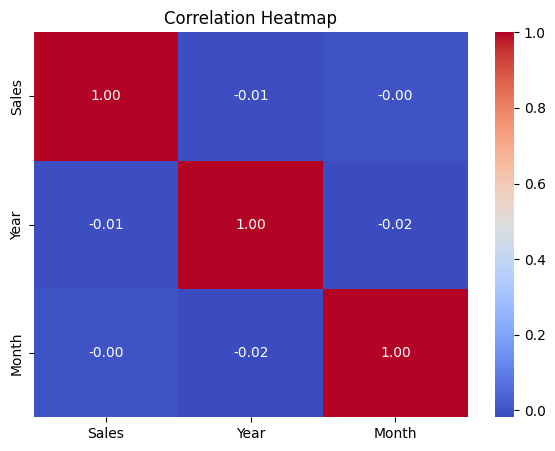

In [63]:
corr_data = df[['Sales', 'Year', 'Month']]

plt.figure(figsize=(7, 5))

sns.heatmap(
    corr_data.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

In [64]:
top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


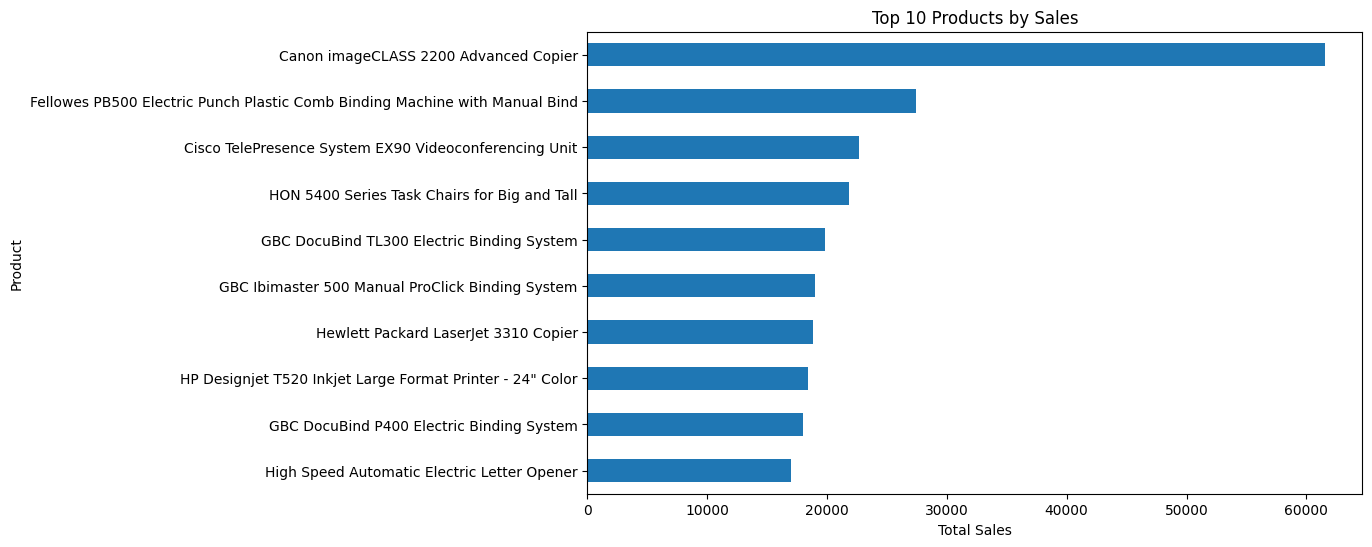

In [65]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product')

plt.show()

In [66]:
monthly_sales = (
    df.groupby('Month_Year')['Sales']
    .sum()
    .reset_index()
)

monthly_sales.head()

,Month_Year,Sales
0,2015-01,14205.707
1,2015-02,4519.892
2,2015-03,55205.797
3,2015-04,27906.855
4,2015-05,23644.303


In [67]:
monthly_sales['Month_Year'] = monthly_sales['Month_Year'].dt.to_timestamp()

In [68]:
monthly_sales.head()

,Month_Year,Sales
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


In [69]:
print("Number of months:", len(monthly_sales))

Number of months: 48


In [71]:
monthly_sales.tail()

,Month_Year,Sales
43,2018-08-01,62837.8480
44,2018-09-01,86152.8880
45,2018-10-01,77448.1312
46,2018-11-01,117938.1550
47,2018-12-01,83030.3888


In [72]:
split_index = int(len(monthly_sales) * 0.8)

train = monthly_sales.iloc[:split_index]
test = monthly_sales.iloc[split_index:]

print("Training months:", len(train))
print("Testing months:", len(test))

Training months: 38
Testing months: 10


In [73]:
X_train = train[['Time_Index', 'Month']]
y_train = train['Sales']

X_test = test[['Time_Index', 'Month']]
y_test = test['Sales']

KeyError: "None of [Index(['Time_Index', 'Month'], dtype='object')] are in the [columns]"

In [74]:
# Create monthly sales
monthly_sales = (
    df.groupby('Month_Year')['Sales']
    .sum()
    .reset_index()
)

# Convert Month_Year to datetime
monthly_sales['Month_Year'] = monthly_sales['Month_Year'].dt.to_timestamp()

# Create time-related columns
monthly_sales['Year'] = monthly_sales['Month_Year'].dt.year
monthly_sales['Month'] = monthly_sales['Month_Year'].dt.month

# Create sequential time index
monthly_sales['Time_Index'] = np.arange(len(monthly_sales))

# Check the result
print(monthly_sales.head())
print("\nColumns:")
print(monthly_sales.columns.tolist())

  Month_Year      Sales  Year  Month  Time_Index
0 2015-01-01  14205.707  2015      1           0
1 2015-02-01   4519.892  2015      2           1
2 2015-03-01  55205.797  2015      3           2
3 2015-04-01  27906.855  2015      4           3
4 2015-05-01  23644.303  2015      5           4

Columns:
['Month_Year', 'Sales', 'Year', 'Month', 'Time_Index']


In [75]:
split_index = int(len(monthly_sales) * 0.8)

train = monthly_sales.iloc[:split_index].copy()
test = monthly_sales.iloc[split_index:].copy()

print("Training months:", len(train))
print("Testing months:", len(test))

Training months: 38
Testing months: 10


In [76]:
X_train = train[['Time_Index', 'Month']]
y_train = train['Sales']

X_test = test[['Time_Index', 'Month']]
y_test = test['Sales']

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (38, 2)
y_train shape: (38,)
X_test shape: (10, 2)
y_test shape: (10,)


In [77]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [78]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    'Month': test['Month_Year'],
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

results

,Month,Actual Sales,Predicted Sales
38,2018-03-01,58863.4128,36770.670002
39,2018-04-01,35541.9101,41587.266087
40,2018-05-01,43825.9822,46403.862172
41,2018-06-01,48190.7277,51220.458256
42,2018-07-01,44825.1040,56037.054341
43,2018-08-01,62837.8480,60853.650425
44,2018-09-01,86152.8880,65670.246510
45,2018-10-01,77448.1312,70486.842594
46,2018-11-01,117938.1550,75303.438679
47,2018-12-01,83030.3888,80120.034763


In [79]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 17217.12099644094
R² Score: 0.48630074218354


In [80]:
print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 17217.12099644094
R² Score: 0.48630074218354


In [81]:
monthly_model = monthly_sales.copy()

month_dummies = pd.get_dummies(
    monthly_model['Month'],
    prefix='Month',
    drop_first=True
)

monthly_model = pd.concat(
    [monthly_model[['Month_Year', 'Sales', 'Time_Index']], month_dummies],
    axis=1
)

monthly_model.head()

,Month_Year,Sales,Time_Index,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
0,2015-01-01,14205.707,0,False,False,False,False,False,False,False,False,False,False,False
1,2015-02-01,4519.892,1,True,False,False,False,False,False,False,False,False,False,False
2,2015-03-01,55205.797,2,False,True,False,False,False,False,False,False,False,False,False
3,2015-04-01,27906.855,3,False,False,True,False,False,False,False,False,False,False,False
4,2015-05-01,23644.303,4,False,False,False,True,False,False,False,False,False,False,False


In [82]:
split_index = int(len(monthly_model) * 0.8)

train = monthly_model.iloc[:split_index].copy()
test = monthly_model.iloc[split_index:].copy()

print("Training months:", len(train))
print("Testing months:", len(test))

Training months: 38
Testing months: 10


In [83]:
feature_columns = [
    col for col in monthly_model.columns
    if col.startswith('Time_Index') or col.startswith('Month_')
]

X_train = train[feature_columns]
y_train = train['Sales']

X_test = test[feature_columns]
y_test = test['Sales']

In [84]:
print(X_train.shape)
print(X_test.shape)

(38, 13)
(10, 13)


In [86]:
feature_columns = ['Time_Index'] + [
    col for col in monthly_model.columns
    if col.startswith('Month_') and col != 'Month_Year'
]

print(feature_columns)

['Time_Index', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']


In [87]:
X_train = train[feature_columns]
y_train = train['Sales']

X_test = test[feature_columns]
y_test = test['Sales']

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (38, 12)
X_test shape: (10, 12)


In [88]:
from sklearn.linear_model import LinearRegression

model_improved = LinearRegression()

model_improved.fit(X_train, y_train)

print("Improved model trained successfully!")

Improved model trained successfully!


In [89]:
y_pred_improved = model_improved.predict(X_test)

In [90]:
from sklearn.metrics import mean_squared_error, r2_score

rmse_improved = np.sqrt(
    mean_squared_error(y_test, y_pred_improved)
)

r2_improved = r2_score(
    y_test,
    y_pred_improved
)

print("Improved RMSE:", rmse_improved)
print("Improved R² Score:", r2_improved)

Improved RMSE: 14478.822640485063
Improved R² Score: 0.6367092236884078


In [91]:
results_improved = pd.DataFrame({
    'Month': test['Month_Year'],
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred_improved
})

results_improved

,Month,Actual Sales,Predicted Sales
38,2018-03-01,58863.4128,57590.052280
39,2018-04-01,35541.9101,44933.690980
40,2018-05-01,43825.9822,48106.907980
41,2018-06-01,48190.7277,43902.259347
42,2018-07-01,44825.1040,44923.522480
43,2018-08-01,62837.8480,42846.020480
44,2018-09-01,86152.8880,82670.168713
45,2018-10-01,77448.1312,52036.048647
46,2018-11-01,117938.1550,88761.179480
47,2018-12-01,83030.3888,90836.587713


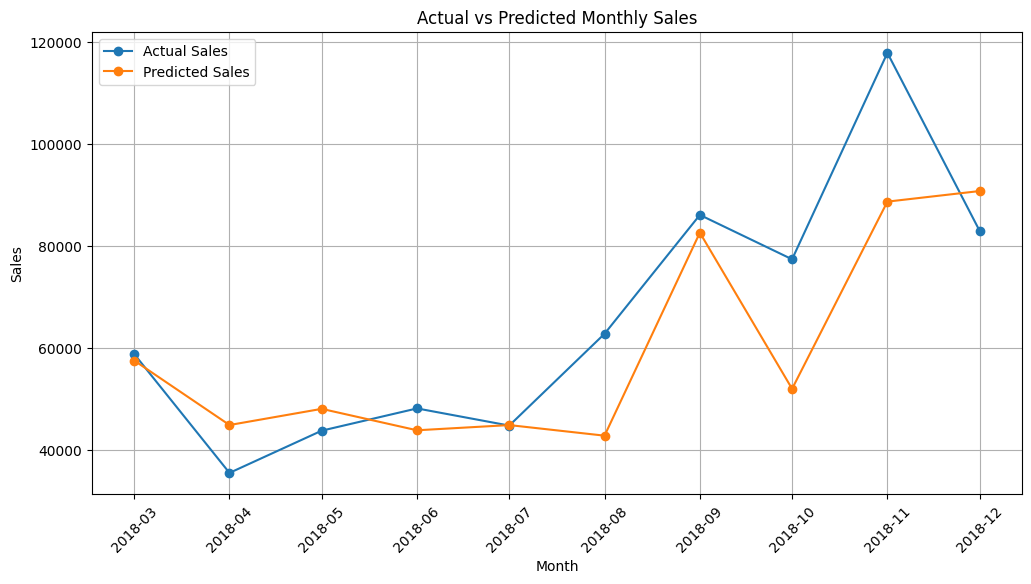

In [92]:
plt.figure(figsize=(12, 6))

plt.plot(
    results_improved['Month'],
    results_improved['Actual Sales'],
    marker='o',
    label='Actual Sales'
)

plt.plot(
    results_improved['Month'],
    results_improved['Predicted Sales'],
    marker='o',
    label='Predicted Sales'
)

plt.title('Actual vs Predicted Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

In [93]:
model_comparison = pd.DataFrame({
    'Model': [
        'Original Linear Regression',
        'Improved Linear Regression'
    ],
    'RMSE': [
        rmse,
        rmse_improved
    ],
    'R2 Score': [
        r2,
        r2_improved
    ]
})

model_comparison

,Model,RMSE,R2 Score
0,Original Linear Regression,17217.120996,0.486301
1,Improved Linear Regression,14478.822640,0.636709


In [94]:
last_month = monthly_sales['Month_Year'].max()

print("Last month in dataset:", last_month)

Last month in dataset: 2018-12-01 00:00:00


In [95]:
future_dates = pd.date_range(
    start=last_month + pd.DateOffset(months=1),
    periods=6,
    freq='MS'
)

future_dates

DatetimeIndex(['2019-01-01', '2019-02-01', '2019-03-01', '2019-04-01',
               '2019-05-01', '2019-06-01'],
              dtype='datetime64[ns]', freq='MS')

In [96]:
future_data = pd.DataFrame({
    'Month_Year': future_dates
})

future_data['Time_Index'] = np.arange(
    len(monthly_sales),
    len(monthly_sales) + 6
)

future_data['Month'] = future_data['Month_Year'].dt.month

future_data

,Month_Year,Time_Index,Month
0,2019-01-01,48,1
1,2019-02-01,49,2
2,2019-03-01,50,3
3,2019-04-01,51,4
4,2019-05-01,52,5
5,2019-06-01,53,6


In [97]:
future_month_dummies = pd.get_dummies(
    future_data['Month'],
    prefix='Month',
    drop_first=True
)

future_model_data = pd.concat(
    [
        future_data[['Month_Year', 'Time_Index']],
        future_month_dummies
    ],
    axis=1
)

In [98]:
future_model_data = future_model_data.reindex(
    columns=feature_columns,
    fill_value=0
)

In [99]:
future_predictions = model_improved.predict(
    future_model_data
)

future_forecast = pd.DataFrame({
    'Month': future_dates,
    'Forecasted Sales': future_predictions
})

future_forecast

,Month,Forecasted Sales
0,2019-01-01,37764.566750
1,2019-02-01,29034.438200
2,2019-03-01,63266.716020
3,2019-04-01,50610.354720
4,2019-05-01,53783.571720
5,2019-06-01,49578.923087


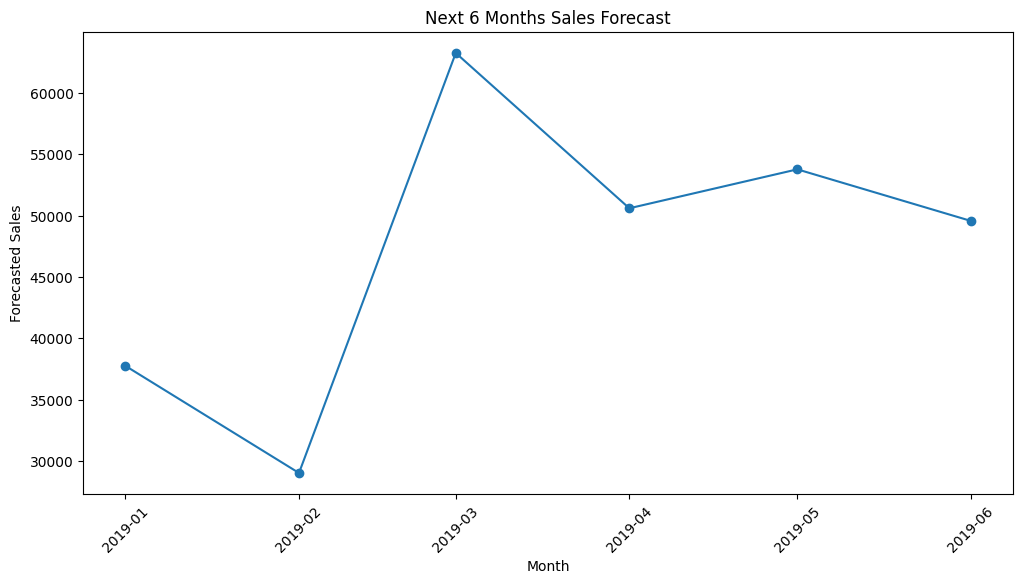

In [100]:
plt.figure(figsize=(12, 6))

plt.plot(
    future_forecast['Month'],
    future_forecast['Forecasted Sales'],
    marker='o'
)

plt.title('Next 6 Months Sales Forecast')
plt.xlabel('Month')
plt.ylabel('Forecasted Sales')
plt.xticks(rotation=45)

plt.show()

In [101]:
print("=" * 50)
print("FINAL SALES ANALYSIS")
print("=" * 50)

# 1. Total sales
print("\n1. TOTAL SALES")
print(f"Total Sales: {df['Sales'].sum():,.2f}")

# 2. Average and median sales
print("\n2. SALES STATISTICS")
print(f"Average Sales: {df['Sales'].mean():,.2f}")
print(f"Median Sales: {df['Sales'].median():,.2f}")
print(f"Standard Deviation: {df['Sales'].std():,.2f}")

# 3. Best category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print("\n3. SALES BY CATEGORY")
print(category_sales)

print(f"\nBest Category: {category_sales.idxmax()}")
print(f"Best Category Sales: {category_sales.max():,.2f}")

# 4. Best region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

print("\n4. SALES BY REGION")
print(region_sales)

print(f"\nBest Region: {region_sales.idxmax()}")
print(f"Best Region Sales: {region_sales.max():,.2f}")

# 5. Top 10 products
top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\n5. TOP 10 PRODUCTS")
print(top_products)

# 6. Sub-category
subcategory_sales = (
    df.groupby('Sub-Category')['Sales']
    .sum()
    .sort_values(ascending=False)
)

print("\n6. SALES BY SUB-CATEGORY")
print(subcategory_sales)

print(f"\nBest Sub-Category: {subcategory_sales.idxmax()}")
print(f"Best Sub-Category Sales: {subcategory_sales.max():,.2f}")

# 7. Best and lowest sales month
monthly_analysis = (
    df.groupby('Month_Year')['Sales']
    .sum()
    .sort_values(ascending=False)
)

print("\n7. MONTHLY SALES")
print(f"Highest Sales Month: {monthly_analysis.idxmax()}")
print(f"Highest Monthly Sales: {monthly_analysis.max():,.2f}")

print(f"Lowest Sales Month: {monthly_analysis.idxmin()}")
print(f"Lowest Monthly Sales: {monthly_analysis.min():,.2f}")

# 8. Model results
print("\n8. MODEL PERFORMANCE")
print(f"Final RMSE: {rmse_improved:,.2f}")
print(f"Final R² Score: {r2_improved:.4f}")

# 9. Future forecast
print("\n9. NEXT 6 MONTH FORECAST")
print(future_forecast.to_string(index=False))

print("\n" + "=" * 50)
print("ANALYSIS COMPLETE")
print("=" * 50)

FINAL SALES ANALYSIS

1. TOTAL SALES
Total Sales: 2,261,536.78

2. SALES STATISTICS
Average Sales: 230.77
Median Sales: 54.49
Standard Deviation: 626.65

3. SALES BY CATEGORY
Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

Best Category: Technology
Best Category Sales: 827,455.87

4. SALES BY REGION
Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

Best Region: West
Best Region Sales: 710,219.68

5. TOP 10 PRODUCTS
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System         

In [102]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Dataset shape: (9800, 21)

Missing values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Month_Year        0
dtype: int64

Duplicate rows:
0

Data types:
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category